#Sugar Trap Analysis

## Installing Libraries Needed

In [53]:
# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


All libraries loaded successfully!


## Story 1: Data Ingestion & "The Clean Up"

In [54]:
# Streams the massive database and truncates it at 500,000 rows to keep things fast
!wget -qO- https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv | head -n 500000 > openfoodfacts.csv

print("downloaded successfully")

downloaded successfully


### Loading the dataset

In [55]:
# Define only the columns required by the project brief
columns_to_keep = ['product_name', 'categories_tags', 'sugars_100g', 'proteins_100g', 'ingredients_text']

# Open Food Facts uses tab separators (\t)
df = pd.read_csv(
    'openfoodfacts.csv',
    sep='\t',
    usecols=columns_to_keep,
    low_memory=False,
    on_bad_lines='skip'  # Skips rows with formatting issues
)

print(f"Successfully loaded a subset containing {df.shape[0]} rows and {df.shape[1]} columns!")

Successfully loaded a subset containing 499999 rows and 5 columns!


### Viewing The  Dataset

In [56]:
df.head()

,product_name,categories_tags,ingredients_text,sugars_100g,proteins_100g
0,Limonade artisanale a la rose,NaN,NaN,NaN,NaN
1,M&amp;M white,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",NaN,NaN
2,Chocolate n3,NaN,NaN,NaN,NaN
3,Pâte de fruits,NaN,NaN,NaN,NaN
4,Paleta gran reserva - Sierra nevada-,"en:beverages-and-beverages-preparations,en:bev...","Thiamin, Biotin, Chromium, Garcinia cambogia f...",NaN,NaN


### Checking Missing Values

In [57]:
missing_values = df.isnull().sum()
percentage_missing = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': percentage_missing
})

print(missing_info.sort_values(by='Percentage', ascending=False))

                  Missing Values  Percentage
sugars_100g               388365   77.673155
proteins_100g             384775   76.955154
ingredients_text          233041   46.608293
categories_tags           231921   46.384293
product_name               15789    3.157806


###  Data Clean Up stage

In [58]:
# Dropping Rows With Missing Values
df.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g'], inplace=True)

### Filter out biologically impossible values(Outiler)

In [59]:
# Nutrients must be between 0g and 100g per 100g
df = df[(df['sugars_100g'] >= 0) & (df['sugars_100g'] <= 100)]
df = df[(df['proteins_100g'] >= 0) & (df['proteins_100g'] <= 100)]
# Ensure combined macros don't physically exceed 100g
df = df[(df['sugars_100g'] + df['proteins_100g']) <= 100]

## Story 2: The Category Wrangler

### Category Wrangler — Empirical Tag Frequency Analysis

In [60]:
# 1. Drop missing values in categories so we can parse them cleanly
categories_series = df['categories_tags'].dropna()

# 2. Split the comma-separated strings into individual tags and clean them
all_tags = []
for row in categories_series:
    # Open Food Facts tags look like "en:snacks,en:sweet-snacks"
    tags = [tag.strip().replace('en:', '') for tag in str(row).split(',')]
    all_tags.extend(tags)

# 3. Count the occurrences of each unique tag
tag_counts = Counter(all_tags)

# 4. Convert to a DataFrame to view the top 30 most common tags
top_tags_df = pd.DataFrame(tag_counts.most_common(30), columns=['Tag Keyword', 'Frequency'])
print("--- Top 30 Most Frequent Tags in Your Dataset ---")
print(top_tags_df)

--- Top 30 Most Frequent Tags in Your Dataset ---
                          Tag Keyword  Frequency
0     plant-based-foods-and-beverages      21741
1                   plant-based-foods      20165
2                cereals-and-potatoes      12514
3                              snacks       9063
4                              breads       7153
5                             dairies       6797
6                        sweet-snacks       6036
7                     fermented-foods       5961
8             fermented-milk-products       5907
9                            desserts       5374
10         cereals-and-their-products       5048
11                     dairy-desserts       4106
12           fermented-dairy-desserts       4024
13                            yogurts       3969
14                          beverages       3690
15                         condiments       3631
16                         breakfasts       3342
17  fruits-and-vegetables-based-foods       3041
18                 

### Cleaning the Categorical Tag Column

In [61]:
# The categories_tags column looks like this:
# "en:snacks,en:sweet-snacks,en:biscuits,en:chocolate-biscuits"


df['categories_clean'] = (
    df['categories_tags']   # point at the raw category column
    .fillna('')                  # replace empty cells with empty string
    .str.lower()                 # convert all text to lowercase
    .str.replace(' ', '')        # remove all spaces
)

# create a new column called categories_clean with the cleaned tags
print("Category tags cleaned")
print("\nSample of cleaned tags:\n")
print(df['categories_clean'].head())

Category tags cleaned

Sample of cleaned tags:

689    en:asian-style-ready-meal
690                             
691                             
797                             
829                             
Name: categories_clean, dtype: object


### Creating of the bucket

In [62]:
def assign_category(tag_string):

    # check if any cookie related keywords exist in the tags
    if any(word in tag_string for word in ['biscuit', 'cookie', 'pastry', 'cake', 'baked']):
        return 'Bakery & Biscuits'

    elif any(word in tag_string for word in ['chocolate', 'candy', 'sweet', 'caramel', 'bonbon', 'sugar']):
        return 'Sweets & Candies'

    elif any(word in tag_string for word in ['chip', 'cracker', 'nut', 'popcorn', 'snack', 'crisp', 'salty', 'peanut']):
        return 'Savory Snacks'

    elif any(word in tag_string for word in ['dairy', 'yogurt', 'yoghurt', 'cheese', 'milk', 'creams', 'beurre', 'lait']):
        return 'Dairy Products'

    elif any(word in tag_string for word in ['juice', 'soda', 'beverage', 'drink', 'tea', 'water', 'coffee']):
        return 'Beverages'

    return 'Other'

# apply the logic
df['primary_category'] = df['categories_clean'].apply(assign_category)

print("--- Updated Engineered Primary Category Distribution ---")
print(df['primary_category'].value_counts())

--- Updated Engineered Primary Category Distribution ---
primary_category
Other                69463
Beverages            18897
Dairy Products        7582
Sweets & Candies      5785
Savory Snacks         4505
Bakery & Biscuits     3424
Name: count, dtype: int64


### Dataset for streamlite Visualization

In [63]:
# 1. Filter the dataset to include only our 5 core food/snack categories
df_streamlit = df[df['primary_category'] != 'Other'].copy()

# 2. Keep only the exact columns we need for the dashboard to keep the file size tiny
dashboard_columns = ['product_name', 'primary_category', 'sugars_100g', 'proteins_100g', 'ingredients_text']
df_streamlit = df_streamlit[dashboard_columns]

# 3. Print confirmation and the new file size metric
print(f"✅ Success! Streamlit dataset ")
print(f"📊 Final row count for dashboard: {df_streamlit.shape[0]} products.")

✅ Success! Streamlit dataset 
📊 Final row count for dashboard: 40193 products.


In [64]:
df_streamlit.head()

,product_name,primary_category,sugars_100g,proteins_100g,ingredients_text
840,pasta,Beverages,1.9,6.7,NaN
865,Eirn original curry Sauce,Beverages,29.6,5.2,Wheat Flour Sugar Vegetable Fat D Curry Powder...
875,Donut Milka,Bakery & Biscuits,18.0,6.0,NaN
890,Véritable pâte à tartiner noisettes chocolat noir,Sweets & Candies,32.0,8.0,NaN
892,Familjepack Schnitzel Frysta,Beverages,0.6,13.5,"Water, breadcrumbs 24.5% (wheat flour, sugar, ..."


### Primary Category Distribution

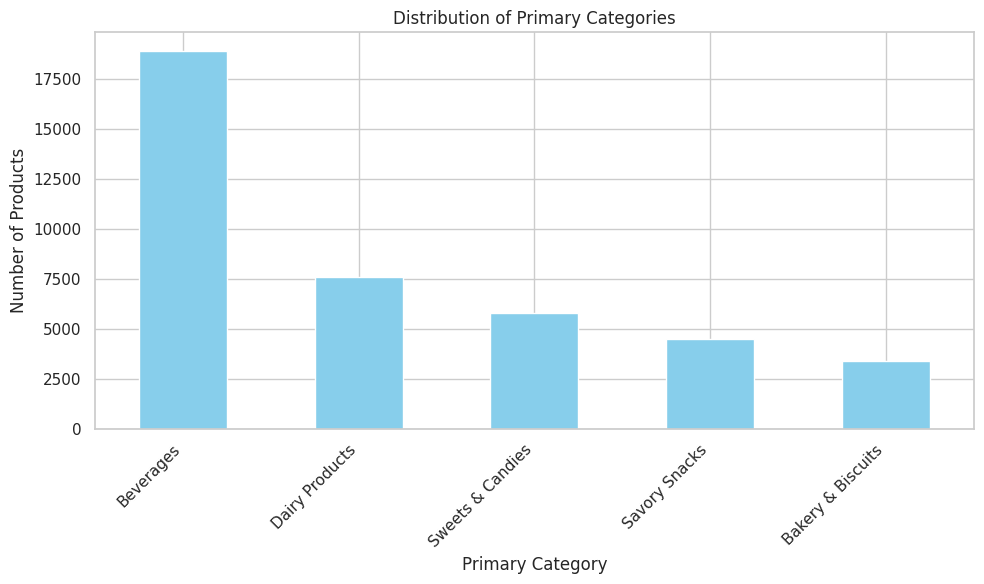

In [65]:
category_distribution = df_streamlit['primary_category'].value_counts()

plt.figure(figsize=(10, 6))
category_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Primary Categories')
plt.xlabel('Primary Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## The "Nutrient Matrix" Visualization

### Scatter Plot For Sugar vs Protien

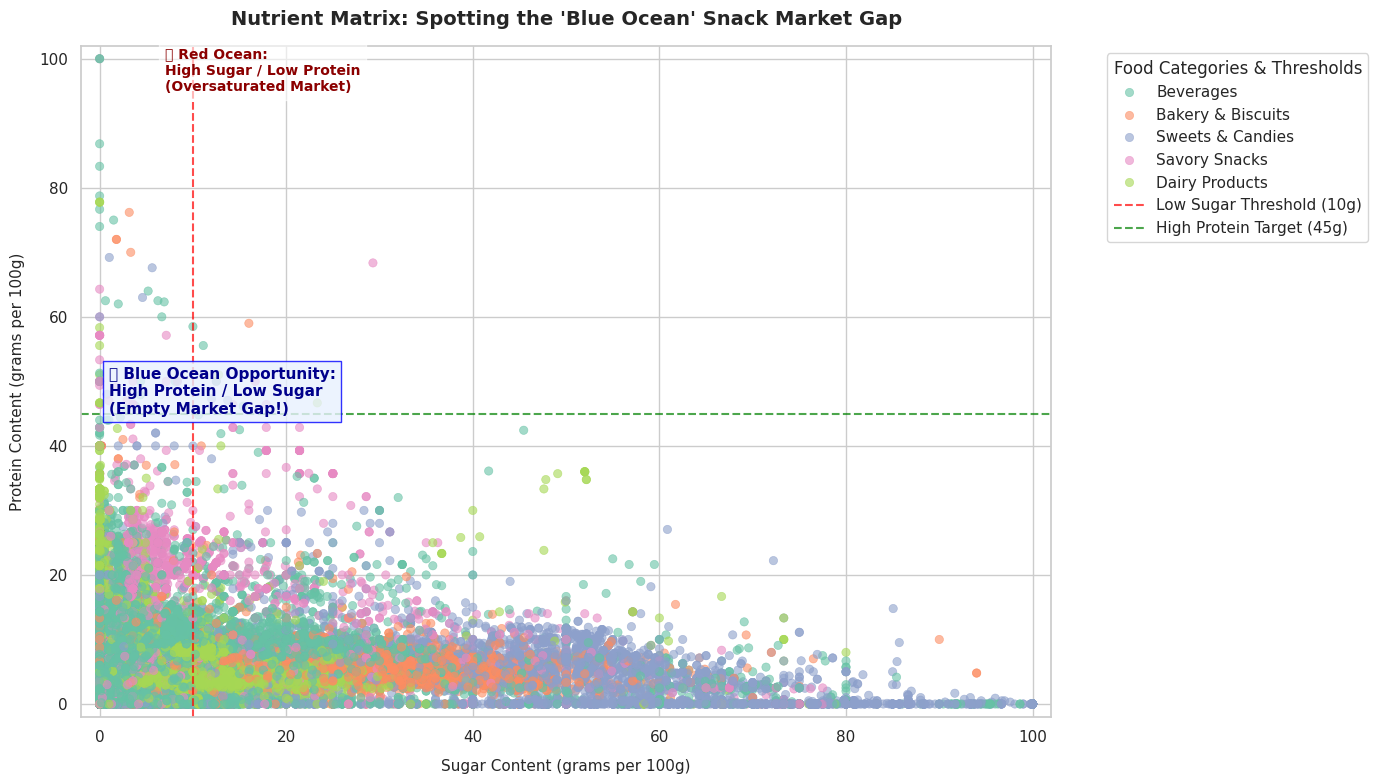

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 1. Create the scatter plot using Seaborn for beautiful grouping
scatter = sns.scatterplot(
    data=df_streamlit,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    alpha=0.6,
    edgecolor=None,
    palette='Set2'
)

# 2. Add strategic quadrant boundary lines (Sugar = 10g, Protein = 45g)
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Low Sugar Threshold (10g)')
plt.axhline(y=45, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='High Protein Target (45g)')

# 3. Annotate the "Blue Ocean" quadrant directly on the chart canvas
plt.text(7, 95, '🟥 Red Ocean:\nHigh Sugar / Low Protein\n(Oversaturated Market)',
         color='darkred', fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6))

plt.text(1, 45, '🟦 Blue Ocean Opportunity:\nHigh Protein / Low Sugar\n(Empty Market Gap!)',
         color='darkblue', fontsize=11, weight='bold', bbox=dict(facecolor='#E8F0FE', alpha=0.8, edgecolor='blue'))

# 4. Customize labels, titles, and limits
plt.title("Nutrient Matrix: Spotting the 'Blue Ocean' Snack Market Gap", fontsize=14, pad=15, weight='bold')
plt.xlabel("Sugar Content (grams per 100g)", fontsize=11, labelpad=10)
plt.ylabel("Protein Content (grams per 100g)", fontsize=11, labelpad=10)

plt.xlim(-2, 102)
plt.ylim(-2, 102)

# Place the legend cleanly outside or inside the plot space
plt.legend(title='Food Categories & Thresholds', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Render the plot statically in the notebook workspace
plt.show()

### Categoical Distribution With respect to Blue Occean


--- Primary Category Distribution in 'Blue Ocean' Products ---


,count
primary_category,
Savory Snacks,29
Beverages,23
Dairy Products,9
Sweets & Candies,5
Bakery & Biscuits,4


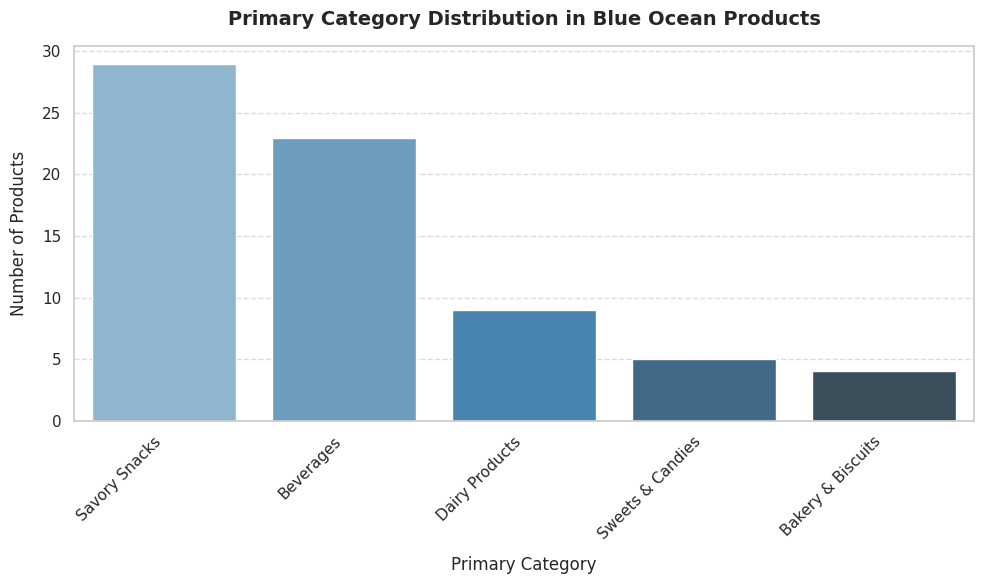

In [67]:
# Ensure thresholds are defined for this cell's execution context
HIGH_PROTEIN_THRESHOLD = 45
LOW_SUGAR_THRESHOLD = 10

# Filter df_streamlit for 'Blue Ocean' products
blue_ocean_products = df_streamlit[
    (df_streamlit['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD) &
    (df_streamlit['sugars_100g'] < LOW_SUGAR_THRESHOLD)
].copy()

# Get the distribution of primary categories within these Blue Ocean products
blue_ocean_category_distribution = blue_ocean_products['primary_category'].value_counts()

print("\n--- Primary Category Distribution in 'Blue Ocean' Products ---")
display(blue_ocean_category_distribution.to_frame())

# Visualize this distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=blue_ocean_category_distribution.index, y=blue_ocean_category_distribution.values, palette='Blues_d')
plt.title('Primary Category Distribution in Blue Ocean Products', fontsize=14, pad=15, weight='bold')
plt.xlabel('Primary Category', fontsize=12, labelpad=10)
plt.ylabel('Number of Products', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### True Blue Ocean Penetration Rate by Category

The raw counts above (`blue_ocean_category_distribution`) are misleading on their own — a category can have
more Blue Ocean products simply because it is a *bigger* category overall, not because it is a bigger
*opportunity*. The cell below normalizes each category's Blue Ocean count by its total size, giving the
**true penetration rate**: the % of each category that is already High Protein / Low Sugar. The lowest
rate is the biggest under-served gap.


--- True Blue Ocean Penetration Rate by Category (%) ---


,blue_ocean_pct
primary_category,
Sweets & Candies,0.086430
Bakery & Biscuits,0.116822
Dairy Products,0.118702
Beverages,0.121712
Savory Snacks,0.643729


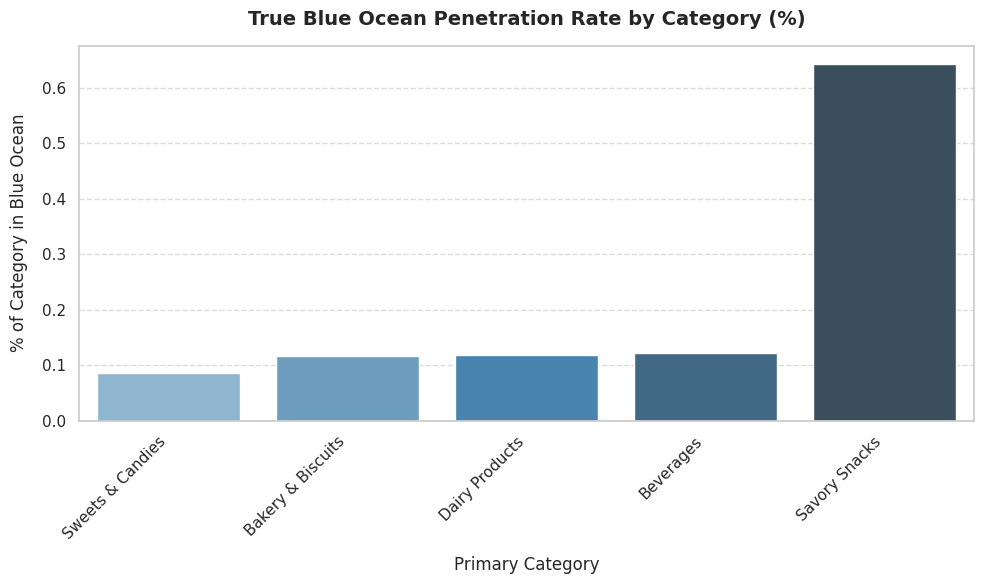

In [68]:
# True penetration rate = Blue Ocean count / total products in that category, as a %
total_by_cat = df_streamlit['primary_category'].value_counts()
blue_by_cat = blue_ocean_products['primary_category'].value_counts()

penetration_rate = (blue_by_cat / total_by_cat * 100).reindex(total_by_cat.index).fillna(0).sort_values()

print("\n--- True Blue Ocean Penetration Rate by Category (%) ---")
display(penetration_rate.to_frame(name='blue_ocean_pct'))

plt.figure(figsize=(10, 6))
sns.barplot(x=penetration_rate.index, y=penetration_rate.values, palette='Blues_d')
plt.title('True Blue Ocean Penetration Rate by Category (%)', fontsize=14, pad=15, weight='bold')
plt.xlabel('Primary Category', fontsize=12, labelpad=10)
plt.ylabel('% of Category in Blue Ocean', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Identify the true opportunity category with their protein and sugar gram

In [69]:
snack_categories = ['Bakery & Biscuits', 'Sweets & Candies', 'Savory Snacks']
opportunity_cat = penetration_rate.reindex(snack_categories).dropna().idxmin()
opp_pct = penetration_rate[opportunity_cat]

comparator_cat = penetration_rate.idxmax()
comparator_pct = penetration_rate[comparator_cat]

# Data-backed target: median protein/sugar of the products that ALREADY succeed in this category's
# Blue Ocean cluster, rather than just restating the flat 45g/10g pass/fail cutoff
opp_blue = blue_ocean_products[blue_ocean_products['primary_category'] == opportunity_cat]
target_protein = opp_blue['proteins_100g'].median()
target_sugar = opp_blue['sugars_100g'].median()

print(f"True opportunity category: {opportunity_cat} ({opp_pct:.3f}% penetration, n={len(opp_blue)} Blue Ocean products)")
print(f"Comparator (highest penetration): {comparator_cat} ({comparator_pct:.3f}% penetration)")
print(f"Data-backed target: >= {target_protein:.0f}g protein and < {target_sugar:.1f}g sugar per 100g")
print()
print("Full penetration ranking for reference:")
display(penetration_rate.sort_values().to_frame(name='blue_ocean_pct'))

True opportunity category: Sweets & Candies (0.086% penetration, n=5 Blue Ocean products)
Comparator (highest penetration): Savory Snacks (0.644% penetration)
Data-backed target: >= 63g protein and < 1.0g sugar per 100g

Full penetration ranking for reference:


,blue_ocean_pct
primary_category,
Sweets & Candies,0.086430
Bakery & Biscuits,0.116822
Dairy Products,0.118702
Beverages,0.121712
Savory Snacks,0.643729


### Analyzing Sweets & Candies in the Blue Ocean



In [70]:
bakery = df_streamlit[df_streamlit['primary_category'] == 'Sweets & Candies']
print(bakery['sugars_100g'].describe())
print(bakery['proteins_100g'].describe())

bakery_blue = bakery[(bakery['proteins_100g'] >= 45) & (bakery['sugars_100g'] < 10)]
print(bakery_blue[['proteins_100g','sugars_100g']].describe())

count    5785.000000
mean       39.625305
std        26.836657
min         0.000000
25%        13.000000
50%        43.333333
75%        59.800000
max       100.000000
Name: sugars_100g, dtype: float64
count    5785.000000
mean        3.971933
std         5.352742
min         0.000000
25%         0.000000
50%         2.500000
75%         6.666667
max        69.204152
Name: proteins_100g, dtype: float64
       proteins_100g  sugars_100g
count       5.000000     5.000000
mean       61.561957     2.414373
std         8.416703     2.523456
min        48.000000     0.000000
25%        60.000000     0.800000
50%        63.000000     1.038062
75%        67.605634     4.600000
max        69.204152     5.633803


## The Recommendation for R&D

### Key Insight: Market Opportunity

| Category | Blue Ocean penetration |
|---|---|
| **Sweets & Candies** | **0.09%** ← lowest — true opportunity |
| Bakery & Biscuits | 0.12% |
| Dairy Products | 0.12% |
| Beverages | 0.12% |
| Savory Snacks | 0.64% ← highest, already the most common combination |

Sweets & Candies and Bakery & Biscuits are close (0.09% vs. 0.12%), but **Sweets & Candies** has the lowest true penetration and is therefore the biggest under-served gap: almost none of this category's products currently combine a meaningful protein claim with a health-conscious sugar level, despite strong existing consumer demand for the aisle.

**Based on the data, the biggest market opportunity is in Sweets & Candies, specifically targeting products with at least 63g of protein and less than 1.0g of sugar per 100g** this target is not an arbitrary cutoff, but the median profile of the 5 Sweets & Candies products that already succeed in the Blue Ocean quadrant today.

## Bonus User Story: The "Hidden Gem"

###  analyze the ingredients_text of high-protein products

In [71]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Extend stopwords with common generic food terms or words less likely to be specific protein sources
extra_stopwords = {'ingredients', 'text', 'food', 'product', 'contains', 'may', 'contain', 'and', 'or', 'de', 'dehydrated', 'powder', 'extract', 'flour', 'oil', 'from', 'with', 'milk', 'water', 'acid', 'sugar', 'salt', 'fat', 'sweetener', 'vegetable', 'fruit', 'natural', 'flavor', 'concentrate', 'e', 'g', 'l'}
stop_words.update(extra_stopwords)

# Filter for high protein products (not necessarily Blue Ocean, but generally high protein)
high_protein_products_ingredients = df_streamlit[df_streamlit['proteins_100g'] >= 20]['ingredients_text'].dropna()

# Function to tokenize and clean ingredient text
def clean_and_tokenize(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize words
    words = text.split()
    # Remove stopwords and very short words
    return [word for word in words if word not in stop_words and len(word) > 2]

# Apply the cleaning and tokenization
all_high_protein_words = []
for ingredients_list_text in high_protein_products_ingredients:
    all_high_protein_words.extend(clean_and_tokenize(ingredients_list_text))

# Count word frequencies
word_counts = Counter(all_high_protein_words)

print("\n--- Top 30 Most Frequent Words in High-Protein Product Ingredients (excluding common stopwords) ---")
for word, count in word_counts.most_common(30):
    print(f"- {word}: {count}")

print("\nThese words are frequently found in high-protein product ingredient lists and can help inform the creation or refinement of protein source keywords for the dictionary.")


--- Top 30 Most Frequent Words in High-Protein Product Ingredients (excluding common stopwords) ---
- cheese: 760
- pasteurized: 570
- enzymes: 555
- peanuts: 446
- culture: 430
- protein: 427
- vitamin: 418
- starch: 403
- soy: 392
- wheat: 338
- calcium: 330
- corn: 321
- color: 274
- roasted: 240
- sodium: 201
- sunflower: 199
- sea: 199
- organic: 198
- cultured: 198
- annatto: 197
- microbial: 189
- potato: 183
- sel: 179
- lait: 179
- isolate: 178
- natamycin: 175
- cellulose: 172
- almonds: 170
- palm: 164
- yeast: 163

These words are frequently found in high-protein product ingredient lists and can help inform the creation or refinement of protein source keywords for the dictionary.


### Analyzing The 3 Top Protein Sources in Blue Ocean Products

In [72]:
from collections import Counter

# Curated dictionary of protein sources, refined based on ingredient analysis
PROTEIN_SOURCES = {
    "Peanuts": ["peanut", "peanuts"],
    "Almonds": ["almond", "almonds"],
    "Whey": ["whey"],
    "Soy Protein": ["soy", "soy protein", "soya protein", "soja protein"],
    "Pea Protein": ["pea protein"],
    "Milk Protein / Casein": ["milk protein", "casein", "lait"], # 'lait' is French for milk
    "Egg": ["egg white", "egg protein", "egg powder"],
    "Cheese": ["cheese"],
    "Protein Isolate (General)": ["isolate"], # Catches general protein isolates
    "Wheat Protein": ["wheat protein", "wheat gluten"]
}

# 1. Same Blue Ocean filter as before
high_protein_low_sugar_products = df_streamlit[
    (df_streamlit['proteins_100g'] >= 45) &
    (df_streamlit['sugars_100g'] < 10)
]

# 2. Same logic as top_protein_sources() in app.py:
#    - lowercase ingredients text
#    - one match per product (first keyword group that hits, in dict order)
def top_protein_sources(ingredients_series, n=3):
    counts = Counter()
    texts = ingredients_series.dropna().str.lower()
    for text in texts:
        for label, kws in PROTEIN_SOURCES.items():
            if any(kw in text for kw in kws):
                counts[label] += 1
                break  # count once per product, priority order
    total = len(texts) if len(texts) else 1
    ranked = counts.most_common(n)
    return [(label, count, count / total * 100) for label, count in ranked]

# 3. Run it on the Blue Ocean subset
sources = top_protein_sources(high_protein_low_sugar_products['ingredients_text'], n=3)

print("\n--- Top Protein Sources in Blue Ocean Products (High Protein, Low Sugar) ---")
for label, count, pct in sources:
    print(f"- {label}: {count:,} products ({pct:.1f}%)")

print(f"\n(Analysis based on {len(high_protein_low_sugar_products)} products meeting criteria: >=45g Protein, <10g Sugar)")


--- Top Protein Sources in Blue Ocean Products (High Protein, Low Sugar) ---
- Whey: 5 products (10.4%)
- Soy Protein: 5 products (10.4%)
- Cheese: 3 products (6.2%)

(Analysis based on 70 products meeting criteria: >=45g Protein, <10g Sugar)


### Top 3 Most Common Protein Sources in 'Blue Ocean' Products

Based on the ingredient analysis, the top 3 most common protein sources driving high protein content in products meeting the 'Blue Ocean' criteria (Protein >= 45g, Sugar < 10g) are:

1.  **Whey:** Found in 5 products, accounting for 10.4% of the Blue Ocean products.
2.  **Soy Protein:** Also found in 5 products, representing 10.4%.
3.  **Cheese:** Identified in 3 products, making up 6.2%.

These ingredients are frequently found in products that successfully combine high protein with low sugar, making them valuable insights for new product development.

## Candidate's Choice Challenge: Creative Analyst's Value Add

### Complementary Analysis: Quadrant Breakdown of Product Distribution

To provide a quantitative understanding of the market landscape, we can categorize each product into one of four quadrants based on our previously defined thresholds:

*   **Blue Ocean:** High Protein (>= 45g) and Low Sugar (< 10g)
*   **Red Ocean:** Low Protein (< 45g) and High Sugar (>= 10g)
*   **High Protein & High Sugar:** High Protein (>= 45g) and High Sugar (>= 10g)
*   **Low Protein & Low Sugar:** Low Protein (< 45g) and Low Sugar (< 10g)

This breakdown will numerically confirm the insights gained from the visual KDE plot.


--- Product Distribution Across Quadrants ---


,count
quadrant,
Low Protein & Low Sugar,24977
"Red Ocean (Low Protein, High Sugar)",15131
"Blue Ocean (High Protein, Low Sugar)",70
High Protein & High Sugar,15


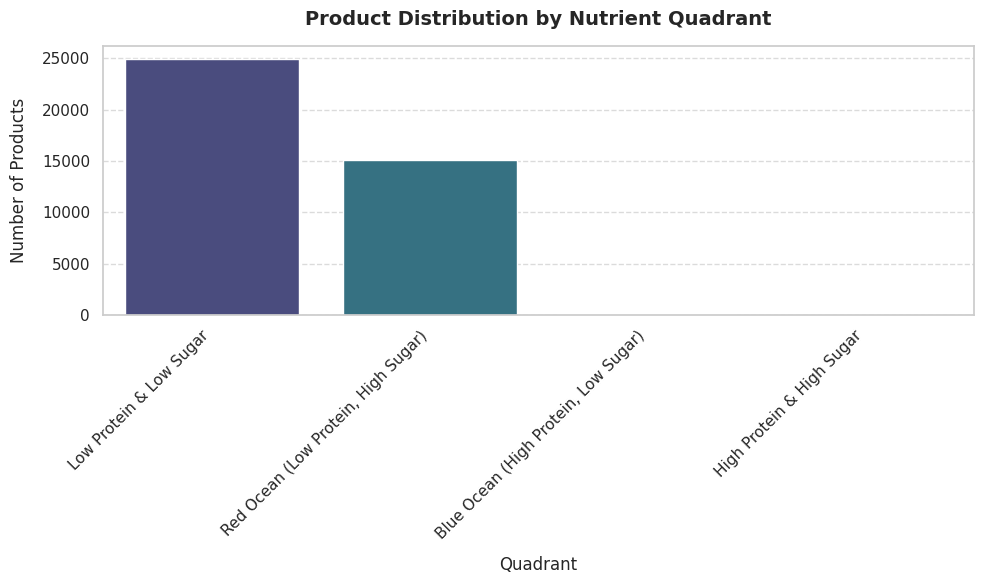

In [73]:
# Define thresholds for High Protein and Low Sugar
HIGH_PROTEIN_THRESHOLD = 45
LOW_SUGAR_THRESHOLD = 10

def assign_quadrant(row):
    is_high_protein = row['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD
    is_low_sugar = row['sugars_100g'] < LOW_SUGAR_THRESHOLD

    if is_high_protein and is_low_sugar:
        return 'Blue Ocean (High Protein, Low Sugar)'
    elif not is_high_protein and not is_low_sugar:
        return 'Red Ocean (Low Protein, High Sugar)'
    elif is_high_protein and not is_low_sugar:
        return 'High Protein & High Sugar'
    else: # not is_high_protein and is_low_sugar
        return 'Low Protein & Low Sugar'

# Apply the function to create a new 'quadrant' column
df_streamlit['quadrant'] = df_streamlit.apply(assign_quadrant, axis=1)

# Calculate the distribution of products in each quadrant
quadrant_counts = df_streamlit['quadrant'].value_counts()

print("\n--- Product Distribution Across Quadrants ---")
display(quadrant_counts.to_frame())

# Visualize the quadrant distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=quadrant_counts.index, y=quadrant_counts.values, palette='viridis')
plt.title('Product Distribution by Nutrient Quadrant', fontsize=14, pad=15, weight='bold')
plt.xlabel('Quadrant', fontsize=12, labelpad=10)
plt.ylabel('Number of Products', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [74]:
# Calculate the detailed breakdown of product counts by quadrant and primary category
quadrant_category_breakdown = pd.crosstab(df_streamlit['quadrant'], df_streamlit['primary_category'])

print("\n--- Detailed Product Count Breakdown by Quadrant and Primary Category ---")
display(quadrant_category_breakdown)

print("\n--- Total Products per Quadrant ---")
display(df_streamlit['quadrant'].value_counts().to_frame())


--- Detailed Product Count Breakdown by Quadrant and Primary Category ---


primary_category,Bakery & Biscuits,Beverages,Dairy Products,Savory Snacks,Sweets & Candies
quadrant,,,,,
"Blue Ocean (High Protein, Low Sugar)",4,23,9,29,5
High Protein & High Sugar,1,4,2,6,2
Low Protein & Low Sugar,981,14464,4802,3632,1098
"Red Ocean (Low Protein, High Sugar)",2438,4406,2769,838,4680



--- Total Products per Quadrant ---


,count
quadrant,
Low Protein & Low Sugar,24977
"Red Ocean (Low Protein, High Sugar)",15131
"Blue Ocean (High Protein, Low Sugar)",70
High Protein & High Sugar,15


### Saving the Final Dataset for Streamlite Visualization

In [75]:
# 1. Save the dataframe as a CSV file in your Colab workspace
# index=False ensures Pandas doesn't add an extra annoying 'Unnamed: 0' row counter column
df_streamlit.to_csv('cleaned_snacks.csv', index=False)

# 2. Print confirmation and the new file size metric
print(f"✅ Success! Save Streamlit dataset ")
print(f"📊 Final row count for dashboard: {df_streamlit.shape[0]} products.")

✅ Success! Save Streamlit dataset 
📊 Final row count for dashboard: 40193 products.
